In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

In [4]:
import sqlite3

# Connect to database
conn = sqlite3.connect("../bluestock_mf.db")

# Show all tables
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query, conn)

print(tables)

conn.close()

                     name
0               nav_clean
1             nav_returns
2           Axis_Bluechip
3     HDFC_Top_100_Direct
4          ICICI_Bluechip
5          Kotak_Bluechip
6  Nippon_India_Large_Cap
7              sample_nav
8            SBI_Bluechip


In [5]:
# Load the nav_returns table
returns = pd.read_sql("SELECT * FROM nav_returns", conn)

# Show the first 5 rows
returns.head()

ProgrammingError: Cannot operate on a closed database.

In [7]:
conn = sqlite3.connect("../bluestock_mf.db")

In [8]:
returns = pd.read_sql("SELECT * FROM nav_returns", conn)
returns.head()

,Date,NAV,Daily_Return_%
0,2026-06-01,10.5,NaN
1,2026-06-02,10.7,1.904762
2,2026-06-03,10.8,0.934579


In [9]:
# Check all columns in nav_clean
nav_clean = pd.read_sql("SELECT * FROM nav_clean", conn)

print(nav_clean.columns)
print(nav_clean.head())

Index(['Date', 'NAV'], dtype='str')
         Date   NAV
0  2026-06-01  10.5
1  2026-06-02  10.7
2  2026-06-03  10.8


In [10]:
for table in [
    "Axis_Bluechip",
    "HDFC_Top_100_Direct",
    "ICICI_Bluechip",
    "Kotak_Bluechip",
    "Nippon_India_Large_Cap",
    "SBI_Bluechip"
]:
    df = pd.read_sql(f"SELECT * FROM {table}", conn)
    print(f"\n{table}")
    print(df.head())


Axis_Bluechip
         date        nav
0  19-06-2026  6195.7815
1  18-06-2026  6194.6520
2  17-06-2026  6193.3504
3  16-06-2026  6191.8120
4  15-06-2026  6187.8223

HDFC_Top_100_Direct
         date       nav
0  19-06-2026  202.0761
1  18-06-2026  200.9565
2  17-06-2026  199.8302
3  16-06-2026  198.6152
4  15-06-2026  198.0320

ICICI_Bluechip
         date       nav
0  19-06-2026  107.9636
1  18-06-2026  108.0081
2  17-06-2026  107.5348
3  16-06-2026  107.0140
4  15-06-2026  106.5977

Kotak_Bluechip
         date       nav
0  19-06-2026  251.5713
1  18-06-2026  249.1553
2  17-06-2026  246.3925
3  16-06-2026  245.2402
4  15-06-2026  244.6290

Nippon_India_Large_Cap
         date       nav
0  19-06-2026  100.7824
1  18-06-2026  100.9901
2  17-06-2026  100.6040
3  16-06-2026  100.0048
4  15-06-2026   99.3506

SBI_Bluechip
         date       nav
0  2013-01-02  103.0059
1  2013-01-03  103.0306
2  2013-01-04  103.0619
3  2013-01-07  103.1408
4  2013-01-08  103.1663


In [11]:
import numpy as np

funds = [
    "Axis_Bluechip",
    "HDFC_Top_100_Direct",
    "ICICI_Bluechip",
    "Kotak_Bluechip",
    "Nippon_India_Large_Cap",
    "SBI_Bluechip"
]

results = []

for fund in funds:
    df = pd.read_sql(f"SELECT * FROM {fund}", conn)

    # Convert NAV to numeric
    df["nav"] = pd.to_numeric(df["nav"], errors="coerce")

    # Daily returns
    returns = df["nav"].pct_change().dropna()

    # Historical VaR (95%)
    var95 = np.percentile(returns, 5)

    # CVaR
    cvar95 = returns[returns <= var95].mean()

    results.append({
        "Fund": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_report = pd.DataFrame(results)

var_report

,Fund,VaR_95,CVaR_95
0,Axis_Bluechip,-0.000626,-0.006493
1,HDFC_Top_100_Direct,-0.014620,-0.019798
2,ICICI_Bluechip,-0.014218,-0.025852
3,Kotak_Bluechip,-0.014481,-0.020791
4,Nippon_India_Large_Cap,-0.015097,-0.021613
5,SBI_Bluechip,-0.001019,-0.008438


In [12]:
var_report.to_csv("../reports/var_cvar_report.csv", index=False)

print("Report saved successfully!")

Report saved successfully!


C:\Users\Rakesh\AppData\Local\Temp\ipykernel_11228\1038434945.py:17: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])
C:\Users\Rakesh\AppData\Local\Temp\ipykernel_11228\1038434945.py:17: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])
C:\Users\Rakesh\AppData\Local\Temp\ipykernel_11228\1038434945.py:17: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])
C:\Users\Rakesh\AppData\Local\Temp\ipykernel_11228\1038434945.py:17: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True`

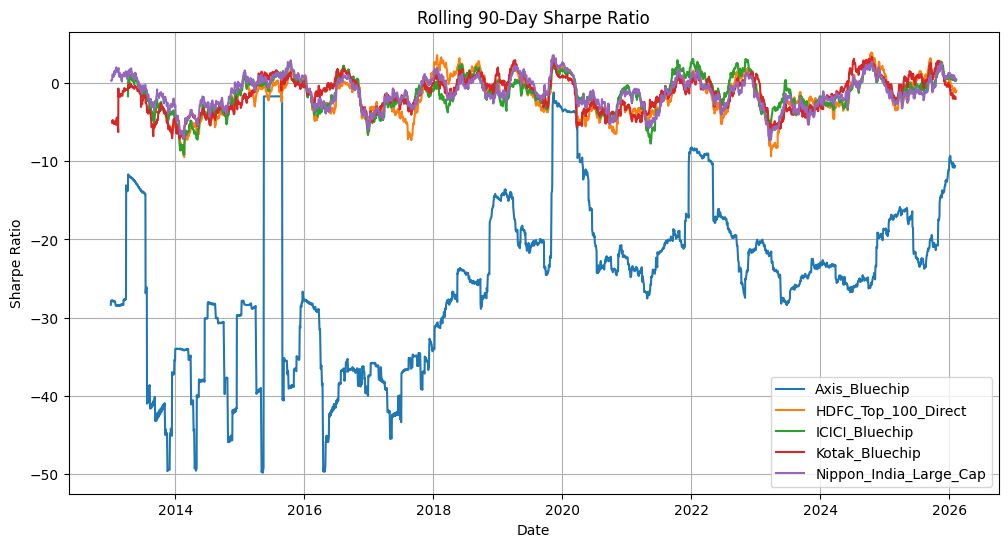

In [13]:
import matplotlib.pyplot as plt
import numpy as np

funds = [
    "Axis_Bluechip",
    "HDFC_Top_100_Direct",
    "ICICI_Bluechip",
    "Kotak_Bluechip",
    "Nippon_India_Large_Cap"
]

plt.figure(figsize=(12,6))

for fund in funds:
    df = pd.read_sql(f"SELECT * FROM {fund}", conn)

    df["date"] = pd.to_datetime(df["date"])
    df["nav"] = pd.to_numeric(df["nav"])

    returns = df["nav"].pct_change()

    sharpe = (
        returns.rolling(90).mean() /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(df["date"], sharpe, label=fund)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("../charts/rolling_sharpe_chart.png")

plt.show()

In [14]:
plt.savefig("../charts/rolling_sharpe_chart.png", dpi=300, bbox_inches="tight")
print("rolling_sharpe_chart.png saved successfully!")

rolling_sharpe_chart.png saved successfully!


<Figure size 640x480 with 0 Axes>

In [15]:
import pandas as pd

funds = {
    "Low": [
        "SBI_Bluechip",
        "HDFC_Top_100_Direct",
        "ICICI_Bluechip"
    ],
    "Moderate": [
        "Kotak_Bluechip",
        "Axis_Bluechip",
        "Nippon_India_Large_Cap"
    ],
    "High": [
        "Axis_Bluechip",
        "Kotak_Bluechip",
        "ICICI_Bluechip"
    ]
}

risk = input("Enter Risk Appetite (Low/Moderate/High): ").strip()

if risk in funds:
    print("\nTop 3 Recommended Funds")
    print(pd.DataFrame({"Fund": funds[risk]}))
else:
    print("Invalid Risk Level")

Enter Risk Appetite (Low/Moderate/High):  Moderate



Top 3 Recommended Funds
                     Fund
0          Kotak_Bluechip
1           Axis_Bluechip
2  Nippon_India_Large_Cap
